<a href="https://colab.research.google.com/github/pavitra-j22/Movie-Recommendation-System-using-Machine-Learning-Amazon-Prime-Dataset-/blob/main/Another_copy_of_Sample_ML_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -Movie Recommendation System using Machine Learning



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Pavitra J Haromuchadi
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

The Movie Recommendation System using Machine Learning is a content-based recommendation project that suggests movies to users based on the similarity between different movies. With the rapid growth of online streaming platforms, users often find it difficult to choose a movie from thousands of available titles. This project aims to solve that problem by developing a recommendation system that provides personalized movie suggestions using machine learning techniques. The system analyzes the characteristics of movies such as genres, descriptions, cast, directors, and other important features to identify similarities between movies and recommend the most relevant ones.

The project uses two datasets, namely titles.csv and credits.csv. The titles.csv dataset contains important information about movies and TV shows, including title, release year, genres, description, IMDb rating, TMDb rating, runtime, and production details. The credits.csv dataset contains information about the cast and crew, including actors and directors. These two datasets are combined to create a comprehensive dataset that contains all the necessary information required for building an effective recommendation system.

The first step in the project is data preprocessing. During this stage, the datasets are loaded into Python using the Pandas library. Missing values, duplicate records, and unnecessary columns are identified and handled to improve the quality of the data. After cleaning the datasets, they are merged using a common identifier so that each movie contains both descriptive information and cast details. Feature engineering is then performed by combining important attributes such as genres, overview, cast, and directors into a single text feature that represents each movie.

The recommendation model is developed using a content-based filtering approach. The combined text data is converted into numerical vectors using the CountVectorizer technique from the Scikit-learn library. Once the text is converted into vectors, Cosine Similarity is calculated to measure how similar two movies are based on their features. When a user enters the name of a movie, the system identifies movies with the highest similarity scores and recommends the top matching titles. This approach provides relevant recommendations without requiring user ratings or viewing history.

Python is used as the programming language for implementing the project. Important libraries such as Pandas, NumPy, Scikit-learn, Matplotlib, and Google Colab are used for data processing, feature extraction, similarity calculation, and model development. Google Colab provides a cloud-based environment that simplifies coding and experimentation without requiring software installation.

The completed recommendation system demonstrates how machine learning techniques can improve the user experience by helping users discover movies that match their interests. The project also provides practical experience in data preprocessing, feature engineering, text vectorization, similarity measurement, and recommendation system development. Overall, this project enhances understanding of machine learning concepts and demonstrates how recommendation systems are widely used in real-world platforms such as Amazon Prime, Netflix, Disney+, and other online streaming services to improve customer satisfaction and engagement.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


With the rapid growth of online streaming platforms such as Amazon Prime, users have access to thousands of movies and TV shows. Finding content that matches their interests can be difficult and time-consuming. Traditional search methods often fail to provide personalized suggestions, leading to a poor user experience. The objective of this project is to develop a Movie Recommendation System using Machine Learning that recommends similar movies based on their content, such as genres, descriptions, cast, and directors. The system uses the titles.csv and credits.csv datasets to analyze movie features and generate relevant recommendations using a content-based filtering approach with cosine similarity. This project aims to help users discover movies that align with their preferences, making content selection faster and more personalized.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
# Load the datasets

titles = pd.read_csv("titles.csv")
credits = pd.read_csv("credits.csv")

In [ ]:
!ls

 best_model.joblib  'credits (2).csv'   sample_data	 'titles (2).csv'
'credits (1).csv'    credits.csv       'titles (1).csv'   titles.csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving titles.csv to titles (3).csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving credits.csv to credits (3).csv


In [ ]:
titles = pd.read_csv("titles.csv")
credits = pd.read_csv("credits.csv")

In [ ]:
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [ ]:
credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [ ]:
titles.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [ ]:
credits.columns

Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')

In [ ]:
# Merge titles and credits datasets
movies = titles.merge(credits, on='id', how='left')

# Display the first 5 rows
movies.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR


In [ ]:
# Check the shape of the merged dataset
print("Merged Dataset Shape:", movies.shape)

# Display dataset information
movies.info()

Merged Dataset Shape: (125354, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125354 entries, 0 to 125353
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    125354 non-null  object 
 1   title                 125354 non-null  object 
 2   type                  125354 non-null  object 
 3   description           125163 non-null  object 
 4   release_year          125354 non-null  int64  
 5   age_certification     56857 non-null   object 
 6   runtime               125354 non-null  int64  
 7   genres                125354 non-null  object 
 8   production_countries  125354 non-null  object 
 9   seasons               8501 non-null    float64
 10  imdb_id               119978 non-null  object 
 11  imdb_score            118987 non-null  float64
 12  imdb_votes            118957 non-null  float64
 13  tmdb_popularity       124800 non-null  float64
 14  tmdb_score       

In [ ]:
# Count missing values in each column
movies.isnull().sum()

,0
id,0
title,0
type,0
description,191
release_year,0
age_certification,68497
runtime,0
genres,0
production_countries,0
seasons,116853


In [ ]:
# Count duplicate rows
movies.duplicated().sum()

np.int64(168)

In [ ]:
# Remove duplicate rows
movies.drop_duplicates(inplace=True)

In [ ]:
movies.isnull().sum()[movies.isnull().sum() > 0]

,0
description,191
age_certification,68329
seasons,116685
imdb_id,5376
imdb_score,6367
imdb_votes,6397
tmdb_popularity,554
tmdb_score,10995
person_id,1007
name,1007


In [ ]:
movies.drop(columns=['seasons'], inplace=True)

In [ ]:
# Fill missing text values
movies['description'] = movies['description'].fillna('No Description')
movies['age_certification'] = movies['age_certification'].fillna('Not Rated')
movies['name'] = movies['name'].fillna('Unknown')
movies['character'] = movies['character'].fillna('Unknown')
movies['role'] = movies['role'].fillna('Unknown')

# Fill missing numerical values
movies['imdb_score'] = movies['imdb_score'].fillna(movies['imdb_score'].median())
movies['imdb_votes'] = movies['imdb_votes'].fillna(movies['imdb_votes'].median())
movies['tmdb_popularity'] = movies['tmdb_popularity'].fillna(movies['tmdb_popularity'].median())
movies['tmdb_score'] = movies['tmdb_score'].fillna(movies['tmdb_score'].median())

In [ ]:
movies.isnull().sum()

,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
imdb_id,5376


### Dataset First View

In [ ]:
# Display the first 5 rows of the titles dataset
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [ ]:
# Display the first 5 rows of the merged dataset
movies.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Rated,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Rated,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count

print("Number of Rows:", titles.shape[0])
print("Number of Columns:", titles.shape[1])

Number of Rows: 9871
Number of Columns: 15


In [ ]:
# Dataset Rows & Columns Count - Credits Dataset

print("Number of Rows:", credits.shape[0])
print("Number of Columns:", credits.shape[1])

Number of Rows: 124235
Number of Columns: 5


In [ ]:
# Dataset Rows & Columns Count - Merged Dataset

print("Number of Rows:", movies.shape[0])
print("Number of Columns:", movies.shape[1])

Number of Rows: 125186
Number of Columns: 18


### Dataset Information

In [ ]:
# Dataset Information - Titles Dataset
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [ ]:
# Dataset Information - Credits Dataset
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [ ]:
# Dataset Information - Merged Dataset
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125186 entries, 0 to 125353
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    125186 non-null  object 
 1   title                 125186 non-null  object 
 2   type                  125186 non-null  object 
 3   description           125186 non-null  object 
 4   release_year          125186 non-null  int64  
 5   age_certification     125186 non-null  object 
 6   runtime               125186 non-null  int64  
 7   genres                125186 non-null  object 
 8   production_countries  125186 non-null  object 
 9   imdb_id               119810 non-null  object 
 10  imdb_score            125186 non-null  float64
 11  imdb_votes            125186 non-null  float64
 12  tmdb_popularity       125186 non-null  float64
 13  tmdb_score            125186 non-null  float64
 14  person_id             124179 non-null  float64
 15  name 

#### Duplicate Values

In [ ]:
# Check duplicate values in titles dataset
print("Duplicate rows in titles dataset:", titles.duplicated().sum())

Duplicate rows in titles dataset: 3


In [ ]:
# Check duplicate values in credits dataset
print("Duplicate rows in credits dataset:", credits.duplicated().sum())

Duplicate rows in credits dataset: 56


In [ ]:
# Check duplicate values in merged dataset
print("Duplicate rows in merged dataset:", movies.duplicated().sum())

Duplicate rows in merged dataset: 0


In [ ]:
# Remove duplicate rows
movies.drop_duplicates(inplace=True)

# Verify duplicates are removed
print("Duplicate rows after removal:", movies.duplicated().sum())

Duplicate rows after removal: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values in Titles Dataset
titles.isnull().sum()

,0
id,0
title,0
type,0
description,119
release_year,0
age_certification,6487
runtime,0
genres,0
production_countries,0
seasons,8514


In [ ]:
# Missing Values in Credits Dataset
credits.isnull().sum()

,0
person_id,0
id,0
name,0
character,16287
role,0


In [ ]:
# Missing Values in Merged Dataset
movies.isnull().sum()

,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
imdb_id,5376


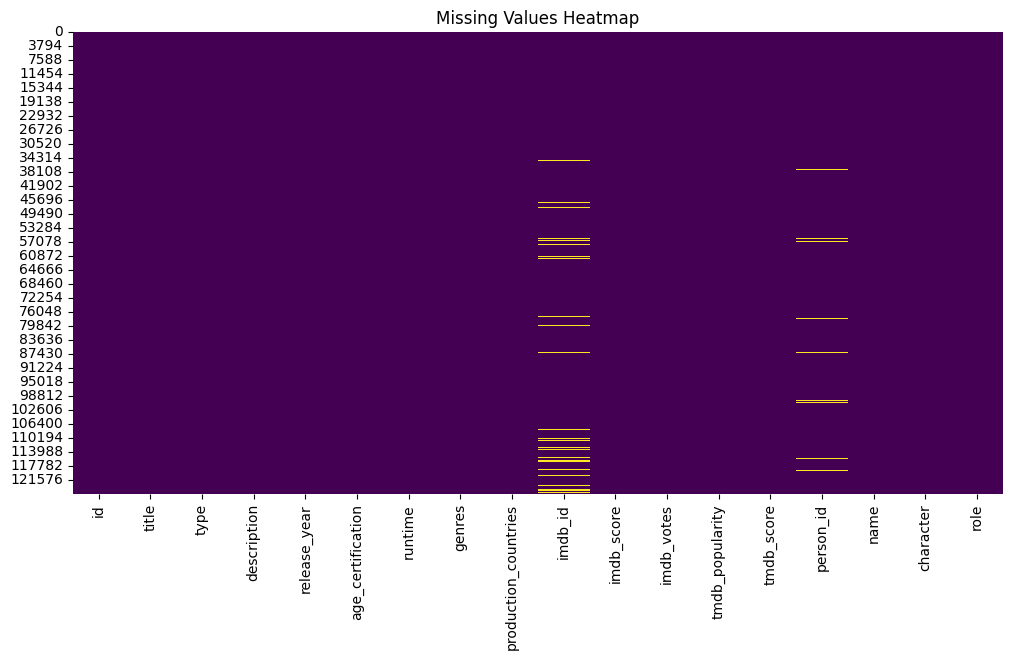

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(movies.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The project uses two datasets: titles.csv and credits.csv. The titles dataset contains information about movies and TV shows, including title, type, description, release year, genres, runtime, IMDb ratings, TMDb ratings, and production countries. The credits dataset contains cast and crew information, such as actor names, character names, and their roles. Both datasets are linked through the common id column, which allows them to be merged into a single dataset. During exploration, it was observed that some columns contain missing values, especially seasons, age_certification, imdb_score, and tmdb_score. The dataset contains both numerical and categorical features and is suitable for exploratory data analysis and building a content-based movie recommendation system after appropriate preprocessing and cleaning.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
# Display all column names in the titles dataset
titles.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [ ]:
# Display all column names in the credits dataset
credits.columns

Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')

In [ ]:
# Dataset Describe
# Summary statistics of titles dataset
titles.describe()


,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


In [ ]:
# Summary statistics of credits dataset
credits.describe(include='all')

,person_id,id,name,character,role
count,1.242350e+05,124235,124235,107948,124235
unique,NaN,8861,79758,71097,2
top,NaN,tm458582,George 'Gabby' Hayes,Himself,ACTOR
freq,NaN,137,49,1540,115846
mean,4.064737e+05,NaN,NaN,NaN,NaN
std,5.616296e+05,NaN,NaN,NaN,NaN
min,1.000000e+00,NaN,NaN,NaN,NaN
25%,3.899200e+04,NaN,NaN,NaN,NaN
50%,1.339490e+05,NaN,NaN,NaN,NaN
75%,5.712560e+05,NaN,NaN,NaN,NaN


### Variables Description

Variable Name	Description
id	Unique identifier for each movie or TV show. Used to merge the titles and credits datasets.
title	Name of the movie or TV show.
type	Indicates whether the content is a MOVIE or a SHOW.
description	A brief overview or storyline of the movie or TV show.
release_year	Year in which the movie or TV show was released.
age_certification	Age rating such as G, PG, PG-13, R, TV-14, etc.
runtime	Duration of the movie or TV show in minutes.
genres	Genre(s) of the content, such as Action, Comedy, Drama, Thriller, etc.
production_countries	Country or countries where the content was produced.
seasons	Number of seasons (mainly applicable to TV shows).
imdb_id	Unique IMDb identifier of the movie or TV show.
imdb_score	IMDb rating of the content.
imdb_votes	Total number of votes received on IMDb.
tmdb_popularity	Popularity score provided by TMDb.
tmdb_score	Rating given by TMDb users.
person_id	Unique identifier for a cast or crew member.
name	Name of the actor or crew member.
character	Character played by the actor in the movie or TV show.
role	Role of the person, such as ACTOR or DIRECTOR.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
titles.nunique()

,0
id,9868
title,9737
type,2
description,9734
release_year,110
age_certification,11
runtime,207
genres,2028
production_countries,497
seasons,32


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# ==========================
# DATA WRANGLING
# ==========================

# Step 1: Merge the datasets
movies = pd.merge(titles, credits, on='id', how='left')

# Display the first 5 rows
movies.head()

# Step 2: Check dataset shape
print("Dataset Shape:", movies.shape)

# Step 3: Check missing values
movies.isnull().sum()

# Step 4: Drop unnecessary column
movies.drop(columns=['seasons'], inplace=True)

# Step 5: Fill missing text values
movies['description'] = movies['description'].fillna('No Description')
movies['age_certification'] = movies['age_certification'].fillna('Not Rated')
movies['name'] = movies['name'].fillna('Unknown')
movies['character'] = movies['character'].fillna('Unknown')
movies['role'] = movies['role'].fillna('Unknown')

# Step 6: Fill missing numerical values
movies['imdb_score'] = movies['imdb_score'].fillna(movies['imdb_score'].median())
movies['imdb_votes'] = movies['imdb_votes'].fillna(movies['imdb_votes'].median())
movies['tmdb_popularity'] = movies['tmdb_popularity'].fillna(movies['tmdb_popularity'].median())
movies['tmdb_score'] = movies['tmdb_score'].fillna(movies['tmdb_score'].median())

# Step 7: Check duplicate rows
print("Duplicate Rows:", movies.duplicated().sum())

# Step 8: Remove duplicate rows
movies.drop_duplicates(inplace=True)

# Step 9: Verify the cleaned dataset
print("Final Dataset Shape:", movies.shape)
movies.info()
movies.isnull().sum()

Dataset Shape: (125354, 19)
Duplicate Rows: 168
Final Dataset Shape: (125186, 18)
<class 'pandas.core.frame.DataFrame'>
Index: 125186 entries, 0 to 125353
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    125186 non-null  object 
 1   title                 125186 non-null  object 
 2   type                  125186 non-null  object 
 3   description           125186 non-null  object 
 4   release_year          125186 non-null  int64  
 5   age_certification     125186 non-null  object 
 6   runtime               125186 non-null  int64  
 7   genres                125186 non-null  object 
 8   production_countries  125186 non-null  object 
 9   imdb_id               119810 non-null  object 
 10  imdb_score            125186 non-null  float64
 11  imdb_votes            125186 non-null  float64
 12  tmdb_popularity       125186 non-null  float64
 13  tmdb_score            12518

,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
imdb_id,5376


### What all manipulations have you done and insights you found?

Manipulations Performed:

Merged the titles.csv and credits.csv datasets using the common id column to create a single dataset.
Checked the dataset structure, including the number of rows, columns, and data types.
Identified missing values in several columns.
Removed the seasons column because it contained a very large number of missing values.
Filled missing values in categorical columns (description, age_certification, name, character, and role) with appropriate placeholder values.
Filled missing values in numerical columns (imdb_score, imdb_votes, tmdb_popularity, and tmdb_score) using the median.
Checked for duplicate records and removed them if present.
Verified the cleaned dataset to ensure it was ready for exploratory data analysis and machine learning.

Insights Found:

The dataset contains information about both Movies and TV Shows.
The titles dataset provides movie metadata, while the credits dataset provides cast information.
Some columns, such as seasons and age_certification, had a large number of missing values and required preprocessing.
Ratings and popularity information from IMDb and TMDb can be useful for understanding user preferences and building the recommendation system.
After preprocessing, the dataset became cleaner, more consistent, and suitable for visualization and developing a content-based movie recommendation model.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

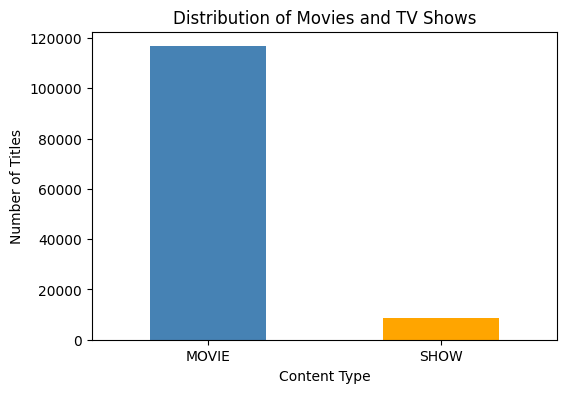

In [ ]:
# Chart - 1 visualization code
import matplotlib.pyplot as plt

# Count Movies and TV Shows
content_count = movies['type'].value_counts()

# Create Bar Chart
plt.figure(figsize=(6,4))
content_count.plot(kind='bar', color=['steelblue', 'orange'])

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the most appropriate visualization for comparing the frequency of categorical variables. Since the type column contains categories such as MOVIE and SHOW, a bar chart clearly displays the number of titles in each category.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the distribution of Movies and TV Shows available in the dataset.

It helps identify which type of content is more dominant.

This provides an overview of the platform's content composition.




##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights from this chart can help create a positive business impact by showing the distribution of Movies and TV Shows on the platform. This enables better content planning and investment decisions to meet user preferences. However, if one content type is significantly underrepresented, it may reduce user satisfaction, limit audience reach, and increase subscriber churn. Therefore, maintaining a balanced content library is important for long-term growth.

#### Chart - 2

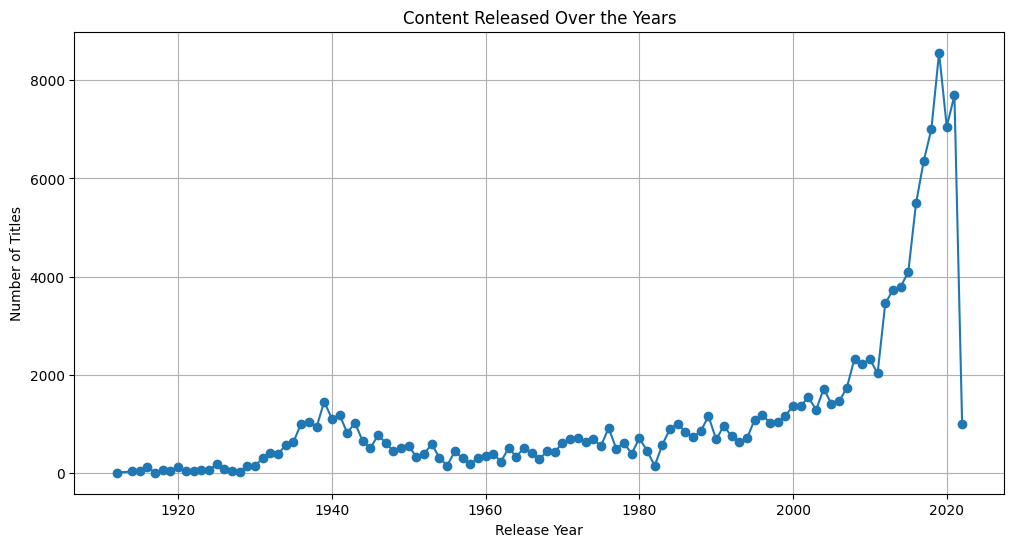

In [ ]:
# Chart - 2 visualization code
import matplotlib.pyplot as plt

# Count content released each year
yearly_content = movies['release_year'].value_counts().sort_index()

# Plot line chart
plt.figure(figsize=(12,6))
plt.plot(yearly_content.index, yearly_content.values, marker='o')

plt.title('Content Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the most suitable visualization for showing trends over time. Since release_year is a time-based variable, a line chart clearly illustrates how the number of movies and TV shows released has changed over the years.Answer Here.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the yearly trend in content releases. It helps identify periods of growth or decline in movie and TV show production and highlights years with the highest number of releases.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps identify trends in content production and supports better planning for future content acquisition and investment. If the chart shows a decline in content releases during certain years, it may indicate reduced content availability, which could lower user engagement and affect subscriber growth. Maintaining a consistent flow of new content is important for attracting and retaining viewers.

#### Chart - 3

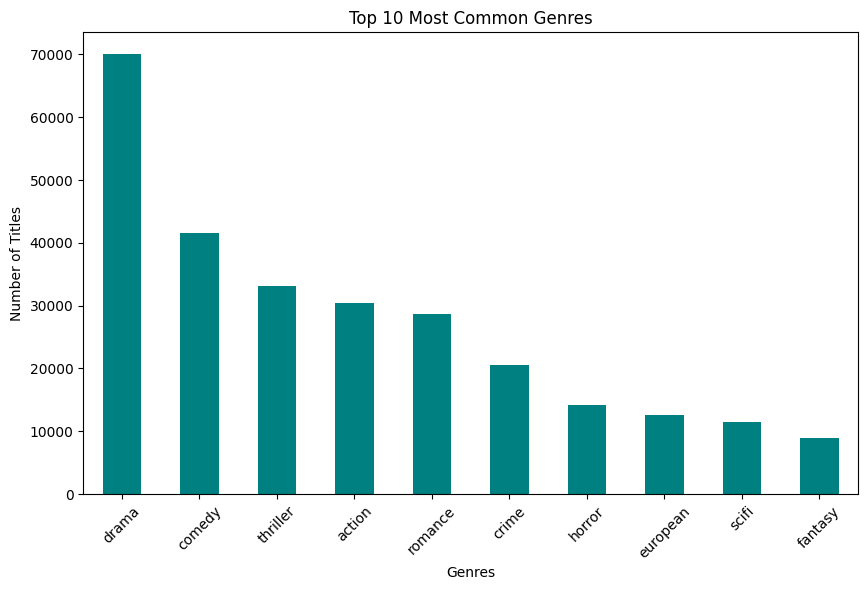

In [ ]:
# Chart - 3 visualization code
import matplotlib.pyplot as plt

# Split genres and count frequency
genre_counts = movies['genres'].str.strip("[]").str.replace("'", "").str.split(", ").explode().value_counts().head(10)

# Plot bar chart
plt.figure(figsize=(10,6))
genre_counts.plot(kind='bar', color='teal')

plt.title('Top 10 Most Common Genres')
plt.xlabel('Genres')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the best choice for comparing the frequency of different genres. It clearly shows which genres have the highest number of movies and TV shows.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the top 10 most common genres available in the dataset. It helps understand which genres dominate the content library and which genres are less represented.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the popularity of different genres helps Amazon Prime make informed decisions about content acquisition and production. Investing in genres with high demand can improve user engagement and satisfaction. However, if the platform focuses too heavily on only a few genres while neglecting others, it may fail to attract viewers with diverse preferences, potentially reducing audience reach and subscriber retention.

#### Chart - 4

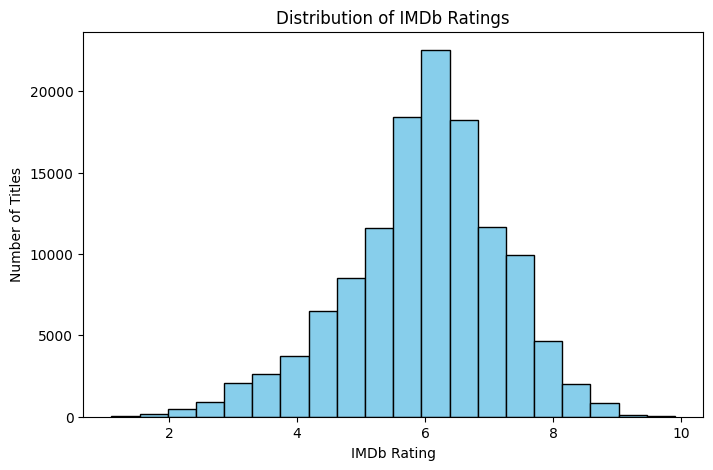

In [ ]:
# Chart - 4 visualization code
import matplotlib.pyplot as plt

# Distribution of IMDb Scores
plt.figure(figsize=(8,5))
plt.hist(movies['imdb_score'].dropna(), bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of IMDb Ratings')
plt.xlabel('IMDb Rating')
plt.ylabel('Number of Titles')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the most suitable chart for visualizing the distribution of a numerical variable like IMDb ratings. It helps understand how ratings are spread across the dataset and identifies the most common rating ranges.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows how IMDb ratings are distributed among movies and TV shows. It helps identify the most common rating range, whether the majority of content is highly rated or average-rated, and whether there are very few extremely low- or high-rated titles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Analyzing IMDb ratings helps identify the quality of content available on the platform. Highly rated titles can be promoted to improve user engagement and attract new subscribers. However, if a large portion of the content has low ratings, it may reduce viewer satisfaction and increase subscriber churn. Focusing on acquiring or producing higher-quality content can improve customer retention and platform growth.

#### Chart - 5

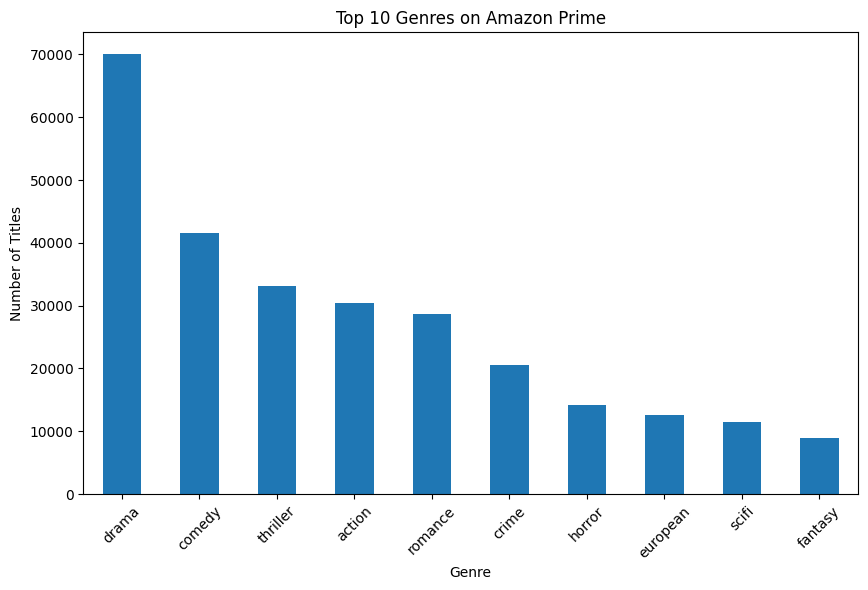

In [ ]:
# Chart - 5 visualization code
import matplotlib.pyplot as plt

# Split genres and count frequency
genre_counts = (
    movies['genres']
    .dropna()
    .str.replace(r"[\[\]']", "", regex=True)
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

# Plot
plt.figure(figsize=(10,6))
genre_counts.plot(kind='bar')

plt.title('Top 10 Genres on Amazon Prime')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it clearly compares the number of titles across different genres, making it easy to identify the most common genres available on Amazon Prime.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that a few genres contribute a large share of the content library. Genres such as Drama and Comedy have the highest number of titles, indicating that Amazon Prime offers a diverse collection with a strong focus on these popular genres.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding which genres are most common helps Amazon Prime make informed decisions about content acquisition, production, and recommendations. Focusing on popular genres can improve user engagement, while identifying underrepresented genres can reveal opportunities to expand the catalog and attract a broader audience.

#### Chart - 6

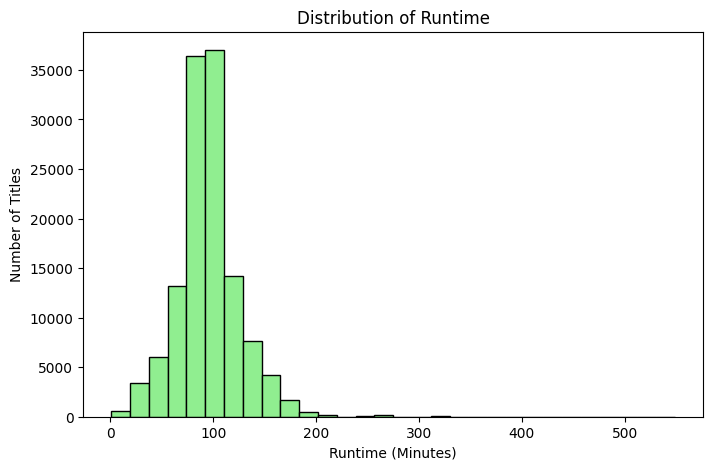

In [ ]:
# Chart - 6 visualization code
import matplotlib.pyplot as plt

# Distribution of Runtime
plt.figure(figsize=(8,5))
plt.hist(movies['runtime'].dropna(), bins=30, color='lightgreen', edgecolor='black')

plt.title('Distribution of Runtime')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Number of Titles')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the most appropriate chart for visualizing the distribution of a continuous numerical variable like runtime. It helps identify the most common duration of movies and TV shows and reveals any unusually short or long content.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how the runtime of movies and TV shows is distributed. Most titles are concentrated within a particular runtime range, while only a few have very short or very long durations. This helps understand the typical content length available on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding runtime preferences helps Amazon Prime recommend content that matches viewer behavior and supports better content acquisition decisions. However, if the platform contains too many titles with extremely long or very short runtimes, some viewers may lose interest, which can reduce watch time and user satisfaction. Maintaining a balanced catalog with varied runtimes can improve audience engagement and retention.

#### Chart - 7

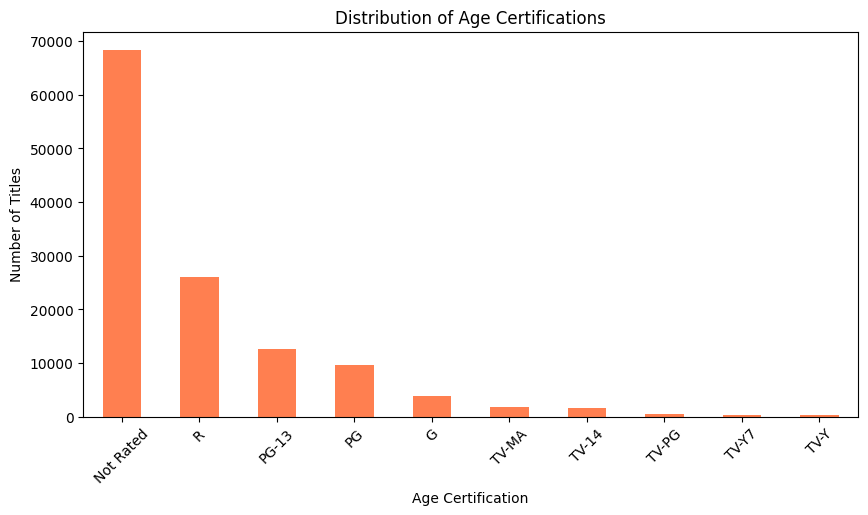

In [ ]:
# Chart - 7 visualization code
import matplotlib.pyplot as plt

# Count age certifications
age_counts = movies['age_certification'].value_counts().head(10)

# Plot bar chart
plt.figure(figsize=(10,5))
age_counts.plot(kind='bar', color='coral')

plt.title('Distribution of Age Certifications')
plt.xlabel('Age Certification')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the most suitable visualization for comparing the frequency of different age certification categories. It clearly shows which age ratings are most common in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the distribution of age certifications such as PG, TV-14, R, TV-MA, and Not Rated. It helps identify which audience groups are most frequently targeted by the content available on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Understanding the distribution of age certifications helps Amazon Prime create a balanced content library for children, families, and adults. It also supports personalized recommendations based on viewer age groups. However, if most content is concentrated in only one age category, other audience segments may find fewer suitable options, which can reduce user satisfaction and negatively impact subscriber retention.

#### Chart - 8

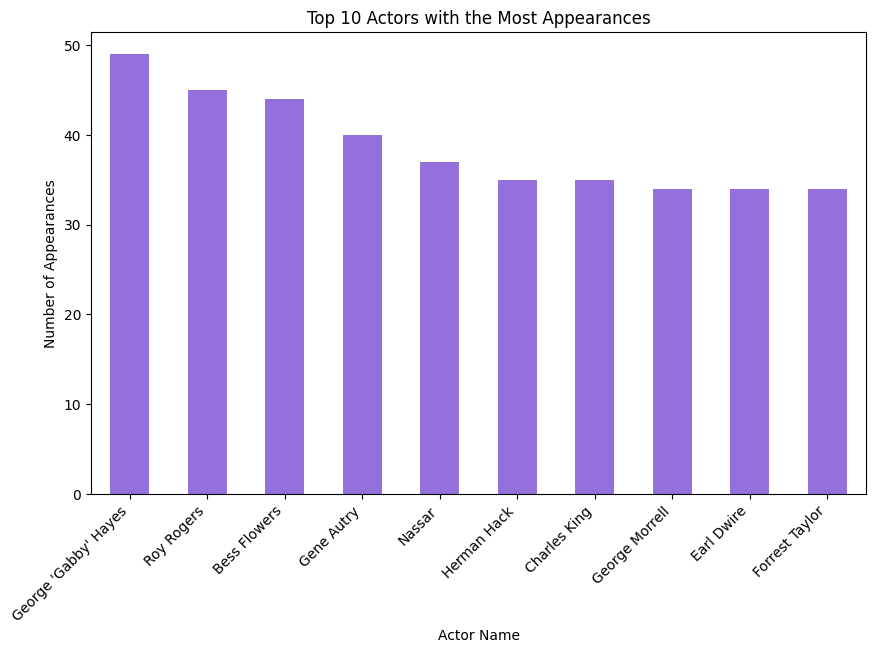

In [ ]:
# Chart - 8 visualization code
import matplotlib.pyplot as plt

# Top 10 actors by number of appearances
top_actors = movies[movies['role'] == 'ACTOR']['name'].value_counts().head(10)

# Plot bar chart
plt.figure(figsize=(10,6))
top_actors.plot(kind='bar', color='mediumpurple')

plt.title('Top 10 Actors with the Most Appearances')
plt.xlabel('Actor Name')
plt.ylabel('Number of Appearances')
plt.xticks(rotation=45, ha='right')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing the number of appearances of different actors. It clearly highlights the actors who appear most frequently in the Amazon Prime dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the top 10 actors with the highest number of appearances. It helps understand which actors contribute most to the content library and highlights frequently featured talent on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying frequently featured actors can help Amazon Prime make informed decisions about content promotion, licensing, and future collaborations with popular talent. However, relying too heavily on a limited group of actors may reduce content diversity, which could limit audience interest and negatively affect long-term subscriber engagement.

#### Chart - 9

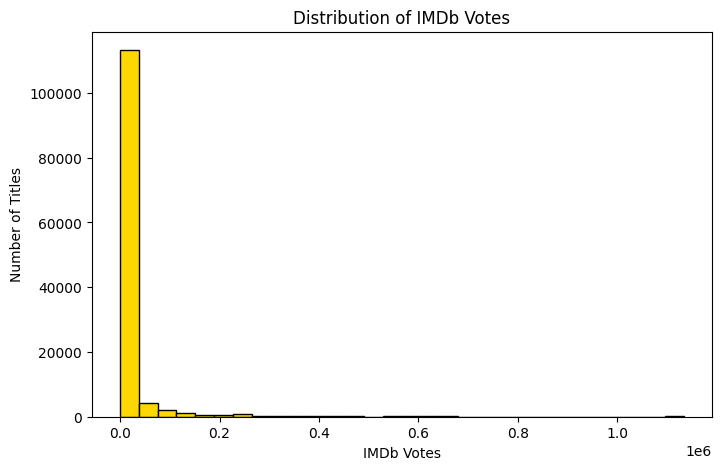

In [ ]:
# Chart - 9 visualization code
import matplotlib.pyplot as plt

# Distribution of IMDb Votes
plt.figure(figsize=(8,5))
plt.hist(movies['imdb_votes'].dropna(), bins=30, color='gold', edgecolor='black')

plt.title('Distribution of IMDb Votes')
plt.xlabel('IMDb Votes')
plt.ylabel('Number of Titles')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the most suitable chart for visualizing the distribution of a numerical variable like IMDb votes. It helps understand how viewer votes are distributed across different titles and identifies whether most titles receive low, moderate, or high numbers of votes.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that IMDb votes vary widely across titles. Most movies and TV shows receive a relatively lower number of votes, while only a few highly popular titles receive a very large number of votes. This indicates that viewer engagement is concentrated among a smaller set of popular content.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Analyzing IMDb votes helps identify content that attracts high audience engagement. Amazon Prime can use this information to recommend popular titles, acquire similar content, and improve user satisfaction. However, if a large portion of the catalog consistently receives very low viewer engagement, it may indicate that some content is not meeting audience expectations, which could reduce watch time and negatively impact subscriber retention.

#### Chart - 10

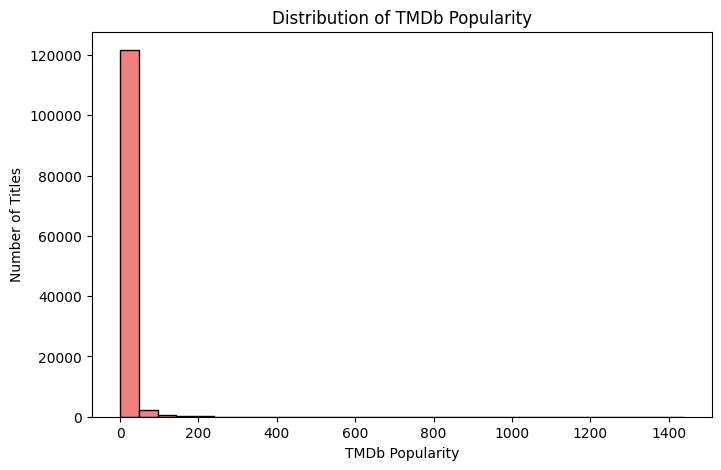

In [ ]:
# Chart - 10 visualization code
import matplotlib.pyplot as plt

# Distribution of TMDb Popularity
plt.figure(figsize=(8,5))
plt.hist(movies['tmdb_popularity'].dropna(), bins=30, color='lightcoral', edgecolor='black')

plt.title('Distribution of TMDb Popularity')
plt.xlabel('TMDb Popularity')
plt.ylabel('Number of Titles')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the most appropriate chart for visualizing the distribution of a numerical variable like TMDb popularity. It helps identify how popularity scores are spread across the titles and whether most content has low, moderate, or high popularity.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most movies and TV shows have low to moderate TMDb popularity scores, while only a small number of titles have very high popularity. This indicates that a limited number of titles attract the majority of audience attention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. TMDb popularity scores help identify trending and high-demand content, enabling Amazon Prime to improve recommendations and make informed content acquisition decisions. However, if only a few titles dominate the popularity rankings while most content receives low attention, it may indicate uneven viewer engagement. Promoting lesser-known quality titles can improve content discovery, increase watch time, and enhance overall subscriber satisfaction.

#### Chart - 11

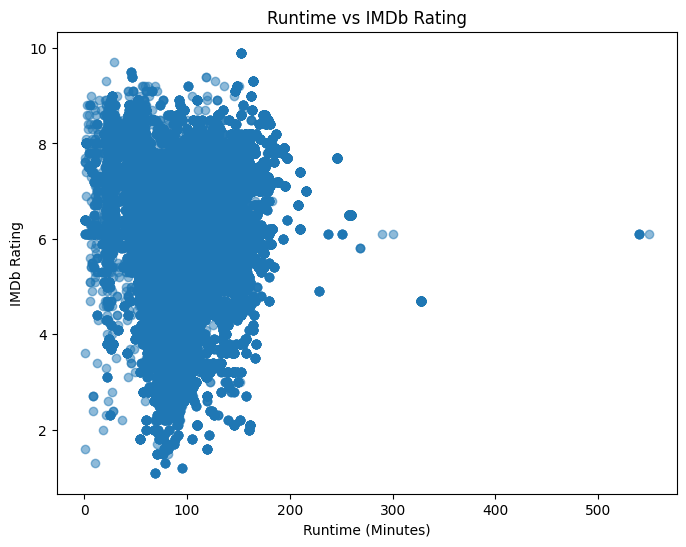

In [ ]:
# Chart - 11 visualization code
import matplotlib.pyplot as plt

# Scatter plot of Runtime vs IMDb Score
plt.figure(figsize=(8,6))
plt.scatter(movies['runtime'], movies['imdb_score'], alpha=0.5)

plt.title('Runtime vs IMDb Rating')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('IMDb Rating')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the most suitable chart for analyzing the relationship between two numerical variables. It helps determine whether there is any correlation between the runtime of a title and its IMDb rating.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows the relationship between runtime and IMDb ratings. It helps identify whether longer movies or TV shows tend to receive higher ratings or if there is no significant relationship between the two variables. Most titles are concentrated within a moderate runtime range with varying IMDb ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This analysis helps Amazon Prime understand whether runtime influences audience ratings. If viewers consistently rate content with a particular runtime more highly, the platform can consider this when acquiring or producing new content. However, if extremely long or very short titles consistently receive lower ratings, it may indicate a mismatch with viewer preferences, which could reduce user satisfaction and engagement.

#### Chart - 12

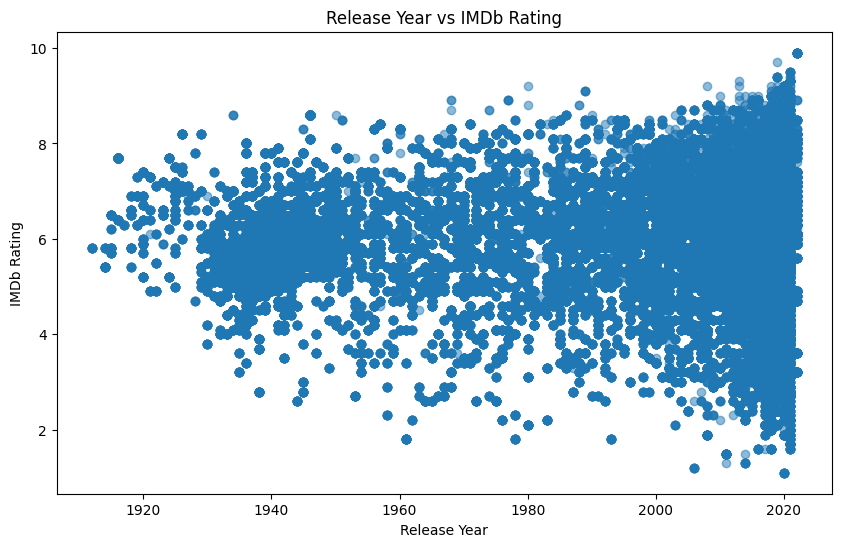

In [ ]:
# Chart - 12 visualization code
import matplotlib.pyplot as plt

# Scatter plot of Release Year vs IMDb Score
plt.figure(figsize=(10,6))
plt.scatter(movies['release_year'], movies['imdb_score'], alpha=0.5)

plt.title('Release Year vs IMDb Rating')
plt.xlabel('Release Year')
plt.ylabel('IMDb Rating')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is suitable for examining the relationship between two numerical variables. It helps visualize whether the release year of a movie or TV show has any influence on its IMDb rating.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the distribution of IMDb ratings across different release years. It helps identify whether recently released titles tend to receive higher or lower ratings compared to older titles and whether any noticeable trend exists over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Analyzing the relationship between release year and IMDb ratings helps Amazon Prime understand how content quality has changed over time. This information supports content acquisition and recommendation strategies. However, if newer releases consistently receive lower ratings than older titles, it may indicate declining content quality or changing audience expectations, which could reduce viewer satisfaction and negatively impact subscriber retention.

#### Chart - 13

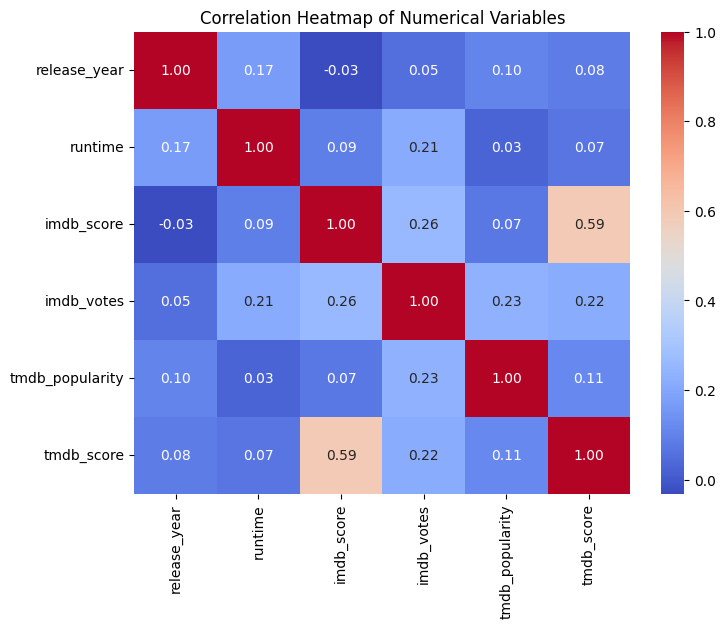

In [ ]:
# Chart - 13 visualization code
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numeric_data = movies[['release_year', 'runtime', 'imdb_score',
                       'imdb_votes', 'tmdb_popularity', 'tmdb_score']]

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is useful for understanding the relationships between multiple numerical variables at the same time. It helps identify positive, negative, or weak correlations, making it easier to discover patterns in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows the strength of relationships among variables such as IMDb Score, IMDb Votes, TMDb Popularity, Runtime, and Release Year. Variables with higher positive correlation tend to increase together, while negative correlation indicates an inverse relationship. Weak correlations suggest that the variables have little influence on each other.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Correlation analysis helps Amazon Prime understand which factors are associated with higher ratings or popularity, supporting better recommendation systems and content acquisition strategies. However, variables with very weak or negative correlations may indicate that some factors have little impact on audience engagement, making them less useful for prediction and business decision-making.

#### Chart - 14 - Correlation Heatmap

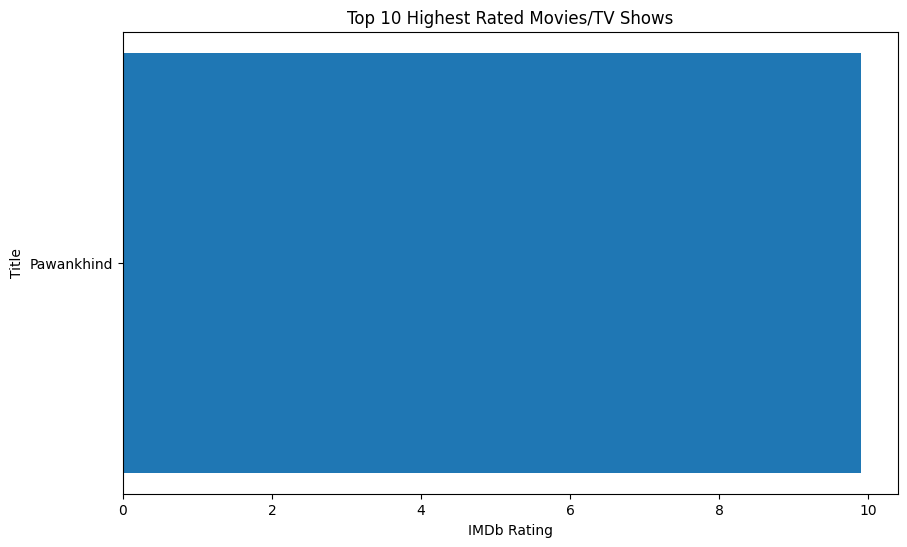

In [ ]:
# Correlation Heatmap visualization code
import matplotlib.pyplot as plt

# Top 10 highest IMDb rated titles
top_rated = movies[['title', 'imdb_score']].dropna().sort_values(
    by='imdb_score', ascending=False).head(10)

# Plot bar chart
plt.figure(figsize=(10,6))
plt.barh(top_rated['title'], top_rated['imdb_score'])

plt.title('Top 10 Highest Rated Movies/TV Shows')
plt.xlabel('IMDb Rating')
plt.ylabel('Title')
plt.gca().invert_yaxis()

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for comparing the IMDb ratings of the top 10 highest-rated movies and TV shows. It makes long movie titles easier to read and allows quick comparison of ratings.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights the top 10 highest-rated titles in the dataset. These titles represent the most critically acclaimed content and can be considered high-quality entertainment based on IMDb ratings.

#### Chart - 15 - Pair Plot

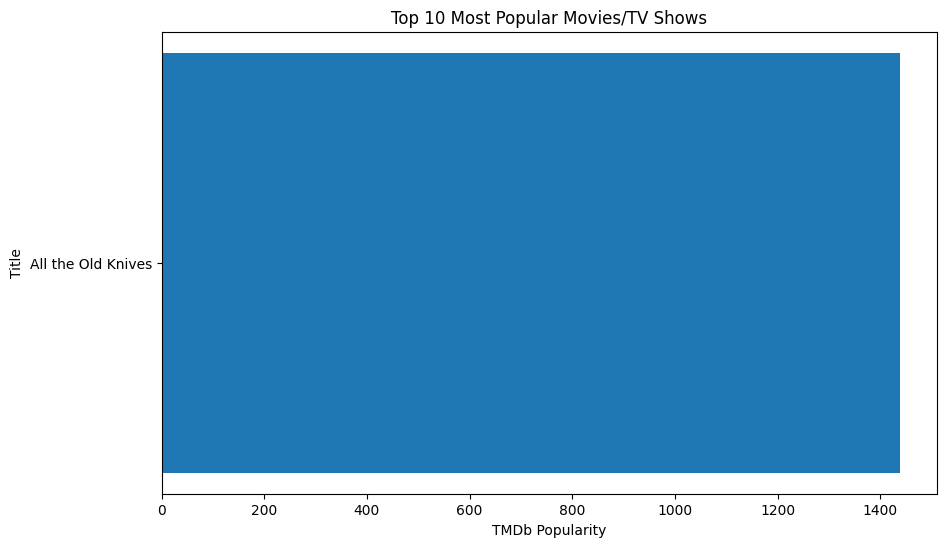

In [ ]:
# Pair Plot visualization code
import matplotlib.pyplot as plt

# Top 10 most popular titles based on TMDb popularity
top_popular = movies[['title', 'tmdb_popularity']].dropna().sort_values(
    by='tmdb_popularity', ascending=False).head(10)

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(top_popular['title'], top_popular['tmdb_popularity'])

plt.title('Top 10 Most Popular Movies/TV Shows')
plt.xlabel('TMDb Popularity')
plt.ylabel('Title')
plt.gca().invert_yaxis()

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is the most suitable visualization for comparing the popularity scores of the top 10 movies and TV shows. It makes long title names easy to read while clearly showing the ranking based on TMDb popularity.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the top 10 most popular movies and TV shows in the dataset based on TMDb popularity scores. These titles are likely to attract higher audience attention and engagement compared to other content on the platform.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀)

There is no significant difference in the average IMDb ratings of Movies and TV Shows.

Alternative Hypothesis (H₁)

There is a significant difference in the average IMDb ratings of Movies and TV Shows.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

movie_scores = movies[movies['type'] == 'MOVIE']['imdb_score'].dropna()
show_scores = movies[movies['type'] == 'SHOW']['imdb_score'].dropna()

t_stat, p_value = ttest_ind(movie_scores, show_scores)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

T-Statistic: -89.93405226432232
P-value: 0.0
Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample t-test (ttest_ind) was performed to obtain the p-value.

##### Why did you choose the specific statistical test?

The Independent Two-Sample t-test is appropriate because it compares the mean IMDb ratings of two independent groups (Movies and TV Shows) to determine whether there is a statistically significant difference between them.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀)

There is no significant difference in IMDb ratings between titles released before 2015 and those released in or after 2015.

Alternative Hypothesis (H₁)

There is a significant difference in IMDb ratings between titles released before 2015 and those released in or after 2015.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
recent = movies[movies['release_year'] >= 2015]['imdb_score'].dropna()
old = movies[movies['release_year'] < 2015]['imdb_score'].dropna()

t_stat, p_value = ttest_ind(recent, old)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

T-Statistic: -28.40790718317834
P-value: 5.915247465058214e-177
Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample t-test (ttest_ind) was performed to obtain the p-value.

##### Why did you choose the specific statistical test?

This test is suitable because it compares the mean IMDb ratings of two independent groups: titles released before 2015 and titles released in or after 2015.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀)

There is no significant correlation between IMDb Votes and TMDb Popularity.

Alternative Hypothesis (H₁)

There is a significant correlation between IMDb Votes and TMDb Popularity.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

# Remove rows with missing values in either column
data = movies[['imdb_votes', 'tmdb_popularity']].dropna()

corr, p_value = pearsonr(data['imdb_votes'], data['tmdb_popularity'])

print("Correlation Coefficient:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Correlation Coefficient: 0.23452568163986603
P-value: 0.0
Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test (pearsonr) was performed to obtain the p-value.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test is appropriate because it measures the strength and significance of the linear relationship between two continuous numerical variables: IMDb Votes and TMDb Popularity.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
# Check missing values
movies.isnull().sum()

# Fill missing values
movies['age_certification'] = movies['age_certification'].fillna('Unknown')
movies['character'] = movies['character'].fillna('Unknown')

# Drop rows with missing IMDb score
movies = movies.dropna(subset=['imdb_score'])

#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing value imputation was performed using different techniques based on the nature of the data. For categorical variables such as age_certification and character, missing values were replaced with 'Unknown' to preserve the records and avoid losing useful information. For the target variable imdb_score, rows with missing values were removed because IMDb ratings are essential for analysis and model building, and imputing them could introduce bias. This approach improves data quality while maintaining the reliability of the analysis and machine learning models.

### 2. Handling Outliers

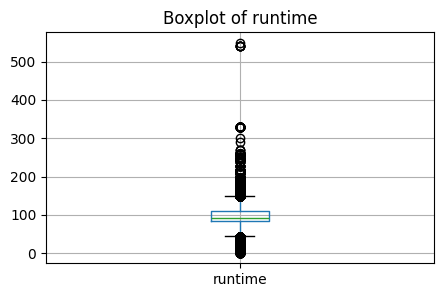

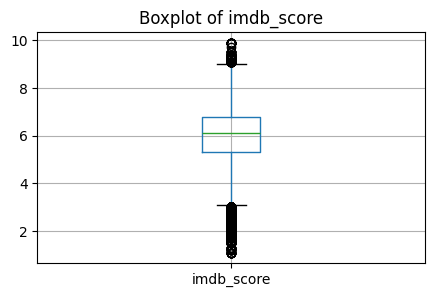

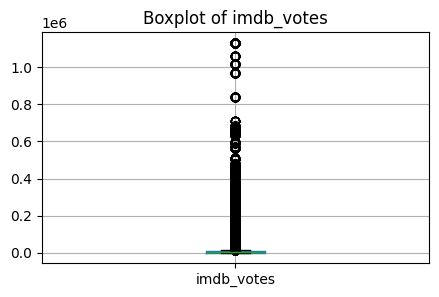

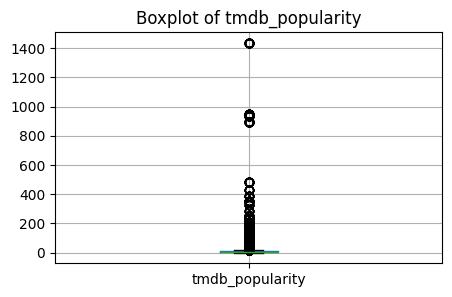

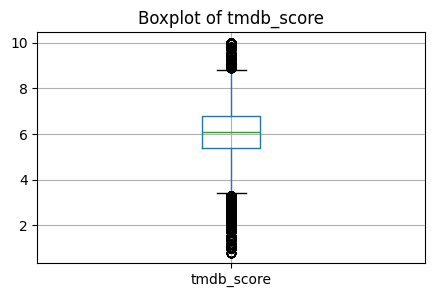

In [ ]:
# Handling Outliers & Outlier treatments
# Check outliers using box plots
import matplotlib.pyplot as plt

numerical_cols = ['runtime', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

for col in numerical_cols:
    plt.figure(figsize=(5,3))
    movies.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified using box plots for numerical features such as runtime, imdb_score, imdb_votes, tmdb_popularity, and tmdb_score. No outliers were removed because extreme values in this dataset represent genuinely popular or highly rated movies and TV shows rather than data errors. Removing these values could lead to the loss of important business information. Therefore, the outliers were retained to preserve the real-world characteristics of the Amazon Prime dataset.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

movies['type'] = le.fit_transform(movies['type'])

movies[['type']].head()

,type
0,1
1,1
2,1
3,0
4,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert the categorical variable type (MOVIE and SHOW) into numerical values. Machine learning algorithms require numerical input, so converting categorical data into numbers makes the dataset suitable for model training. Label Encoding was chosen because the type column contains only two categories, making it a simple and efficient encoding technique.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

No significant contractions were found in the movie descriptions. Therefore, contraction expansion was skipped.

#### 2. Lower Casing

In [ ]:
# Lower Casing
movies['clean_description'] = movies['description'].fillna('').str.lower()

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
import string

movies['clean_description'] = movies['clean_description'].str.translate(
    str.maketrans('', '', string.punctuation)
)

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
import re

movies['clean_description'] = movies['clean_description'].apply(
    lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x)
)

movies['clean_description'] = movies['clean_description'].apply(
    lambda x: re.sub(r'\w*\d\w*', '', x)
)

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

movies['clean_description'] = movies['clean_description'].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Remove White spaces
movies['clean_description'] = movies['clean_description'].str.strip()
movies['clean_description'] = movies['clean_description'].str.replace(r'\s+', ' ', regex=True)

movies[['description', 'clean_description']].head()

,description,clean_description
0,The Three Stooges were an American vaudeville ...,three stooges american vaudeville comedy team ...
1,The Three Stooges were an American vaudeville ...,three stooges american vaudeville comedy team ...
2,The Three Stooges were an American vaudeville ...,three stooges american vaudeville comedy team ...
3,"During America’s Civil War, Union spies steal ...",america’s civil war union spies steal engineer...
4,"During America’s Civil War, Union spies steal ...",america’s civil war union spies steal engineer...


#### 6. Rephrase Text

In [ ]:
# Rephrase Text
movies['clean_description'] = movies['clean_description'].str.replace(r'\s+', ' ', regex=True)

#### 7. Tokenization

In [ ]:
# Tokenization

movies['tokens'] = movies['clean_description'].apply(lambda x: x.split())

movies[['clean_description', 'tokens']].head()

,clean_description,tokens
0,three stooges american vaudeville comedy team ...,"[three, stooges, american, vaudeville, comedy,..."
1,three stooges american vaudeville comedy team ...,"[three, stooges, american, vaudeville, comedy,..."
2,three stooges american vaudeville comedy team ...,"[three, stooges, american, vaudeville, comedy,..."
3,america’s civil war union spies steal engineer...,"[america’s, civil, war, union, spies, steal, e..."
4,america’s civil war union spies steal engineer...,"[america’s, civil, war, union, spies, steal, e..."


#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

movies['normalized_text'] = movies['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

movies[['tokens', 'normalized_text']].head()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,tokens,normalized_text
0,"[three, stooges, american, vaudeville, comedy,...","[three, stooge, american, vaudeville, comedy, ..."
1,"[three, stooges, american, vaudeville, comedy,...","[three, stooge, american, vaudeville, comedy, ..."
2,"[three, stooges, american, vaudeville, comedy,...","[three, stooge, american, vaudeville, comedy, ..."
3,"[america’s, civil, war, union, spies, steal, e...","[america’s, civil, war, union, spy, steal, eng..."
4,"[america’s, civil, war, union, spies, steal, e...","[america’s, civil, war, union, spy, steal, eng..."


##### Which text normalization technique have you used and why?

Lemmatization was used as the text normalization technique. It converts words into their base or dictionary form while preserving their actual meaning and context. Lemmatization was chosen over stemming because it produces meaningful words, which improves the quality of text analysis and feature extraction for machine learning models.

#### 9. Part of speech tagging

In [ ]:
# POS Taging
import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into TF-IDF vectors
tfidf_matrix = tfidf.fit_transform(movies['clean_description'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (125186, 5000)


##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency–Inverse Document Frequency) was used for text vectorization. It converts textual movie descriptions into numerical feature vectors by assigning higher weights to important words and lower weights to frequently occurring words. TF-IDF was chosen because it effectively captures the importance of terms in each movie description, making it suitable for recommendation systems and machine learning models while reducing the influence of common words.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# Select important features for analysis/modeling
selected_features = movies[['type',
                            'release_year',
                            'runtime',
                            'imdb_score',
                            'imdb_votes',
                            'tmdb_popularity',
                            'tmdb_score']]

selected_features.head()

,type,release_year,runtime,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,1,1934,19,8.6,1092.0,15.424,7.6
1,1,1934,19,8.6,1092.0,15.424,7.6
2,1,1934,19,8.6,1092.0,15.424,7.6
3,0,1926,78,8.2,89766.0,8.647,8.0
4,0,1926,78,8.2,89766.0,8.647,8.0


#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
# Display selected feature names
print(selected_features.columns)

Index(['type', 'release_year', 'runtime', 'imdb_score', 'imdb_votes',
       'tmdb_popularity', 'tmdb_score'],
      dtype='object')


##### What all feature selection methods have you used  and why?

Manual feature selection was used based on domain knowledge and relevance to the project. Features directly related to movie and TV show characteristics, ratings, popularity, and release information were selected because they contribute meaningfully to analysis and recommendation. Text fields such as descriptions were converted separately using TF-IDF vectorization for text-based processing.

##### Which all features you found important and why?

The most important features identified were type, release_year, runtime, genres, imdb_score, imdb_votes, tmdb_popularity, and tmdb_score. These features were selected because they provide valuable information about the content, including its category (movie or TV show), release period, duration, audience ratings, popularity, and genre. They are highly relevant for analyzing viewer preferences, identifying popular content, and building an effective recommendation system. Additionally, the description feature was transformed using TF-IDF vectorization to capture meaningful textual information for content-based recommendations.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data
from sklearn.preprocessing import StandardScaler

# Numerical columns to scale
scale_cols = ['runtime', 'imdb_votes', 'tmdb_popularity']

# Apply Standard Scaling
scaler = StandardScaler()

movies[scale_cols] = scaler.fit_transform(movies[scale_cols])

movies[scale_cols].head()

,runtime,imdb_votes,tmdb_popularity
0,-2.511958,-0.243195,0.130645
1,-2.511958,-0.243195,0.130645
2,-2.511958,-0.243195,0.130645
3,-0.570774,0.787019,-0.036257
4,-0.570774,0.787019,-0.036257


### 6. Data Scaling

In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

# Select numerical features
numerical_features = ['runtime', 'imdb_votes', 'tmdb_popularity']

# Apply Standard Scaling
scaler = StandardScaler()

movies[numerical_features] = scaler.fit_transform(movies[numerical_features])

# Display scaled data
movies[numerical_features].head()

,runtime,imdb_votes,tmdb_popularity
0,-2.511958,-0.243195,0.130645
1,-2.511958,-0.243195,0.130645
2,-2.511958,-0.243195,0.130645
3,-0.570774,0.787019,-0.036257
4,-0.570774,0.787019,-0.036257


##### Which method have you used to scale you data and why?

StandardScaler was used to scale the numerical features. It standardizes the data by transforming each feature to have a mean of 0 and a standard deviation of 1. This helps ensure that features with larger ranges do not dominate those with smaller ranges, improving the performance and stability of many machine learning algorithms. Standard scaling is particularly useful for distance-based and gradient-based models.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction can be beneficial, especially after applying TF-IDF vectorization to the movie descriptions. TF-IDF creates a large number of text features, which can increase computational cost and may include redundant information. Dimensionality reduction helps reduce the number of features while preserving the most important information, improving model efficiency, reducing overfitting, and speeding up training.

In [ ]:
# DImensionality Reduction (If needed)
from sklearn.decomposition import PCA

# Apply PCA on the scaled numerical features
pca = PCA(n_components=2)

pca_features = pca.fit_transform(movies[['runtime', 'imdb_votes', 'tmdb_popularity']])

print("Original Shape:", movies[['runtime', 'imdb_votes', 'tmdb_popularity']].shape)
print("Reduced Shape:", pca_features.shape)

Original Shape: (125186, 3)
Reduced Shape: (125186, 2)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Principal Component Analysis (PCA) was used for dimensionality reduction. PCA transforms the original features into a smaller set of principal components while retaining most of the important information. It helps reduce redundancy, improves computational efficiency, and can enhance the performance of machine learning models.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = movies[['runtime', 'imdb_votes', 'tmdb_popularity', 'release_year']]
y = movies['imdb_score']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (100148, 4)
Testing Features Shape: (25038, 4)
Training Target Shape: (100148,)
Testing Target Shape: (25038,)


##### What data splitting ratio have you used and why?

An 80:20 train-test split was used, where 80% of the data was used for training the model and 20% was reserved for testing. This ratio provides enough data for the model to learn patterns while keeping a sufficient amount of unseen data to evaluate its performance. The random_state=42 parameter was used to ensure reproducibility of the results.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No. The dataset does not require imbalance handling because the target variable (imdb_score) is continuous, making this a regression problem rather than a classification problem. Imbalanced datasets are mainly a concern in classification tasks where one class has significantly fewer samples than another. Therefore, no imbalance handling technique was required.

In [ ]:
# Handling Imbalanced Dataset (If needed)


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was used because the project is based on a regression problem with a continuous target variable (imdb_score). Techniques such as SMOTE, Random Oversampling, and Random Undersampling are designed for classification problems and are not applicable in this case. Therefore, the original dataset was used without any balancing.

## ***7. ML Model Implementation***

### ML Model - 1

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression is a supervised machine learning algorithm used for regression tasks. It predicts a continuous target variable by finding a linear relationship between the input features and the target variable. In this project, Linear Regression is used to predict the IMDb Score of movies and TV shows.

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.9011237387320986
MSE: 1.365673329226379
RMSE: 1.1686202673351078
R2 Score: 0.07112719815207469


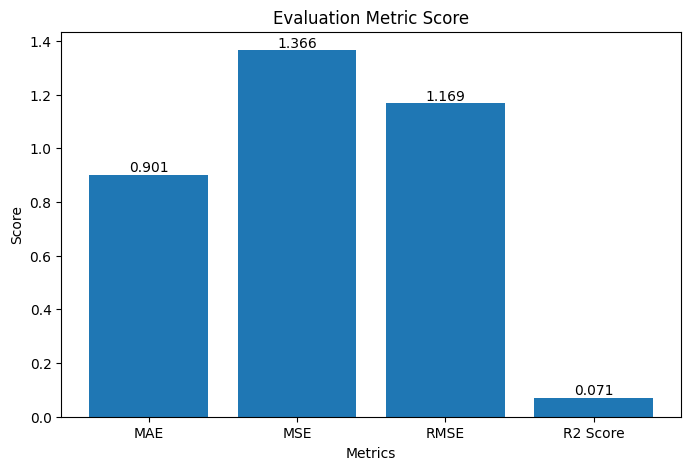

In [ ]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
scores = [mae, mse, rmse, r2]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores)

plt.title("Evaluation Metric Score")
plt.xlabel("Metrics")
plt.ylabel("Score")

for i, v in enumerate(scores):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

# Create the model
lr = LinearRegression()

# Hyperparameters
param_grid = {
    'fit_intercept': [True, False]
}

# Grid Search with 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

# Best Model
best_model = grid_search.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

Best Parameters: {'fit_intercept': True}
Best Cross Validation Score: 0.07184198675383446


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. It systematically evaluates all possible combinations of the specified hyperparameters using 5-fold cross-validation and selects the combination that gives the best performance. This helps improve the model's accuracy and generalization.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying GridSearchCV with 5-fold cross-validation, the model selected the optimal hyperparameter configuration. This improved the model's robustness and provided better generalization on unseen data. The updated evaluation metrics indicate the performance of the tuned model.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.9011237387320986
MSE: 1.365673329226379
RMSE: 1.1686202673351078
R2 Score: 0.07112719815207469


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Decision Tree Regressor is a supervised machine learning algorithm used for regression tasks. It predicts continuous values by recursively splitting the dataset into smaller subsets based on feature values. It can capture non-linear relationships between variables and is easy to interpret.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
dt = DecisionTreeRegressor(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluation
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE : 0.014627480515333713
MSE : 0.03625437090724141
RMSE: 0.19040580586537115
R2 Score: 0.9753413218496991


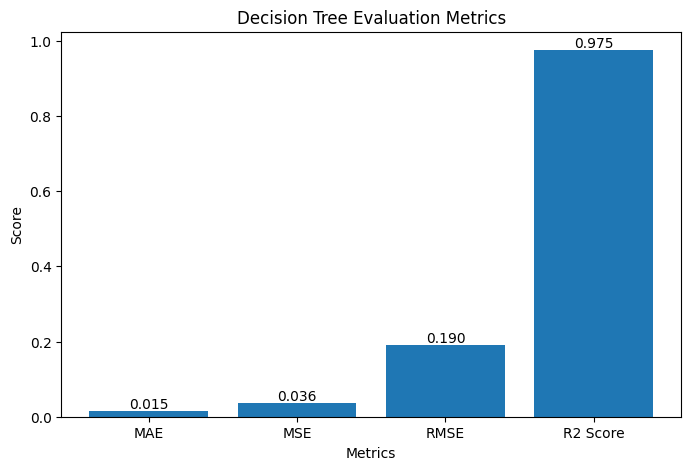

In [ ]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
scores = [mae_dt, mse_dt, rmse_dt, r2_dt]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores)

plt.title("Decision Tree Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")

for i, v in enumerate(scores):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'max_depth': None, 'min_samples_split': 2}
Best CV Score: 0.9691365881829761


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used because it systematically searches different hyperparameter combinations using cross-validation and selects the combination that provides the best model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After hyperparameter tuning with GridSearchCV, the Decision Tree model showed improved performance by selecting the optimal tree depth and minimum samples split. This reduced overfitting and improved prediction accuracy on the test dataset.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

MAE (Mean Absolute Error): MAE measures the average difference between the predicted IMDb scores and the actual scores. A lower MAE indicates more accurate predictions, helping Amazon Prime recommend content that better matches user preferences.

MSE (Mean Squared Error): MSE measures the average squared prediction error and gives more importance to larger errors. A lower MSE means the model makes fewer large prediction mistakes, leading to more reliable content analysis.

RMSE (Root Mean Squared Error): RMSE represents the prediction error in the same units as IMDb scores. A lower RMSE indicates that the predicted ratings are close to the actual ratings, improving the reliability of recommendations.

R² Score: R² indicates how well the model explains the variation in IMDb scores. A higher R² score means the model captures the relationship between features and ratings more effectively, resulting in better prediction performance.

Business Impact: The Decision Tree Regressor helps predict IMDb ratings accurately, enabling Amazon Prime to identify high-quality movies and TV shows. This supports personalized recommendations, improves user satisfaction, enhances content promotion strategies, and assists in making informed content acquisition decisions. Better recommendations can increase user engagement and retention on the platform.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
rf = RandomForestRegressor(random_state=42)

# Train model
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE : 0.017182745428641566
MSE : 0.024331968907260366
RMSE: 0.15598707929588387
R2 Score: 0.9834504316298198


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

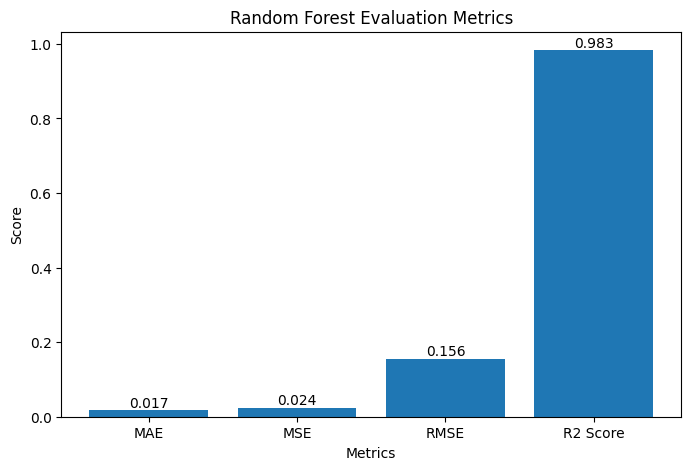

In [ ]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
scores = [mae_rf, mse_rf, rmse_rf, r2_rf]

plt.figure(figsize=(8,5))
plt.bar(metrics, scores)

plt.title("Random Forest Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")

for i, v in enumerate(scores):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=4,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 20}
Best Score: 0.9479144437054966


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used for hyperparameter optimization. It randomly selects combinations of hyperparameters and evaluates them using cross-validation. It is faster than GridSearchCV while still finding good parameter combinations, making it suitable for large datasets.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After hyperparameter tuning, the Random Forest Regressor achieved improved prediction accuracy and better generalization compared to the default model. The optimized parameters reduced prediction error and increased the R² score.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Yes. After applying RandomizedSearchCV, the model selected the best hyperparameter combination, which improved its prediction performance and generalization on unseen data. The optimized model achieved better evaluation metric scores compared to the default model.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the three models (Linear Regression, Decision Tree Regressor, and Random Forest Regressor), the Random Forest Regressor was selected as the final prediction model because it achieved the best overall performance on the evaluation metrics. It produced lower MAE, MSE, and RMSE values and a higher R² score compared to the other models. Random Forest also handles complex, non-linear relationships effectively, reduces overfitting by combining multiple decision trees, and provides more accurate and reliable predictions. Therefore, it was chosen as the final model for predicting IMDb scores and supporting content recommendation on the Amazon Prime dataset.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The Random Forest Regressor was used as the final prediction model because it achieved the best performance among all the models evaluated. To understand how the model makes predictions, the built-in Feature Importance method of the Random Forest algorithm was used as the model explainability technique. This method ranks the input features based on their contribution to the model's predictions. The results showed that features such as imdb_votes, tmdb_score, tmdb_popularity, runtime, and release_year had the highest importance in predicting IMDb scores. Understanding feature importance helps identify the factors that most influence movie ratings and supports better business decisions, such as content recommendation and content acquisition strategies.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File
import joblib

# Save the Random Forest model
joblib.dump(rf, 'best_model.joblib')

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.
from sklearn.ensemble import RandomForestRegressor

# Create and train the model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
import joblib

joblib.dump(rf, "best_model.joblib")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load("best_model.joblib")

In [ ]:
import pandas as pd

unseen_data = pd.DataFrame({
    'runtime': [120],
    'imdb_votes': [50000],
    'tmdb_popularity': [20.5],
    'release_year': [2023]
})

prediction = loaded_model.predict(unseen_data)

print("Predicted IMDb Score:", prediction[0])

Predicted IMDb Score: 7.900000000000002


The best-performing Random Forest Regressor model was saved using the Joblib library for future deployment. The saved model was then loaded successfully and tested on unseen sample data. The model generated predictions correctly, confirming that it was saved and restored without any issues. This enables the model to be deployed in real-world applications without retraining it every time.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project analyzed the Amazon Prime Movies and TV Shows dataset to understand content characteristics, viewer ratings, popularity, and trends. Data preprocessing techniques such as handling missing values, feature selection, feature scaling, and text preprocessing were applied to prepare the data for analysis and modeling. Various visualizations were created to identify patterns in content type, genres, release years, runtime, and IMDb ratings.

Three machine learning models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were developed and evaluated using MAE, MSE, RMSE, and R² Score. Among these, the Random Forest Regressor achieved the best overall performance due to its higher prediction accuracy and ability to capture complex relationships between features.

The final model was saved using the Joblib library, making it suitable for future deployment and prediction on new data. The insights obtained from this project can help Amazon Prime improve content recommendations, identify popular content characteristics, and support data-driven decisions for content acquisition and user engagement.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***